In [1]:
# Environment and Imports

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# Reproducibility
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', 40)
%matplotlib inline

# Homework 6 — Trees: Solutions

This notebook contains solutions for the Homework 6 from the ML Zoomcamp (trees chapter). We will: download the dataset, preprocess it, train tree-based models, evaluate them, and answer the multiple-choice questions. All random seeds are fixed to ensure reproducibility.


## Homework 6 — Problem statements

The following are the homework problems (copied from the assignment):

(Downloaded dataset: https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv)

We will predict `fuel_efficiency_mpg`.

Preparation steps:
- Fill missing values with zeros.
- Do train/validation/test split with 60%/20%/20% distribution.
- Use `train_test_split` with `random_state=1`.
- Use `DictVectorizer(sparse=True)` to turn dataframes into matrices.

Questions:

Q1: Train DecisionTreeRegressor with `max_depth=1`. Which feature is used for splitting the data?

Q2: Train RandomForestRegressor with `n_estimators=10`, `random_state=1`. What's RMSE on validation?

Q3: Try `n_estimators` from 10 to 200 step 10, `random_state=1`. After which value does RMSE stop improving (3 decimal)?

Q4: For `max_depth` in [10,15,20,25], for each depth try `n_estimators` 10..200 step 10 and compute mean RMSE; which depth is best?

Q5: Train RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1). Which of [vehicle_weight, horsepower, acceleration, engine_displacement] is most important?

Q6: Train XGBoost models with given params for 100 rounds using eta=0.3 and eta=0.1. Which eta gives better RMSE on validation?


In [2]:
# Load data

data_url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
df = pd.read_csv(data_url)

print('Data shape:', df.shape)
df.head()

Data shape: (9704, 11)


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [3]:
# Preprocessing

# Fill missing values with zeros

df = df.fillna(0)

# Ensure categorical columns are strings (if any). Let's inspect types.
print(df.dtypes)

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object


In [4]:
# Train / validation / test split (60/20/20)

# First split: train (60%) and temp (40%)
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=RANDOM_STATE)
# Second split: val (20%) and test (20%) from temp (which is 40%) -> each gets 0.5 of temp
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_STATE)

print('Train shape:', train_df.shape)
print('Validation shape:', val_df.shape)
print('Test shape:', test_df.shape)

Train shape: (5822, 11)
Validation shape: (1941, 11)
Test shape: (1941, 11)


In [5]:
# Prepare data for modeling using DictVectorizer

TARGET = 'fuel_efficiency_mpg'

def df_to_dicts(df):
    # drop the target
    features = df.drop(columns=[TARGET]).to_dict(orient='records')
    return features

dv = DictVectorizer(sparse=True)

d_train = df_to_dicts(train_df)
d_val = df_to_dicts(val_df)
d_test = df_to_dicts(test_df)

X_train = dv.fit_transform(d_train)
y_train = train_df[TARGET].values

X_val = dv.transform(d_val)
y_val = val_df[TARGET].values

X_test = dv.transform(d_test)
y_test = test_df[TARGET].values

print('Number of features:', len(dv.get_feature_names_out()))

Number of features: 14


In [6]:
# Helper functions

def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)


def train_model_return_rmse(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return rmse(y_val, preds)

### Question 1 — Decision tree (max_depth=1)

Train DecisionTreeRegressor(max_depth=1) and find which feature is used for splitting.

In [7]:
# Q1: Decision tree with max_depth=1
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

# The tree_.feature attribute gives the index of the feature used for each node
feature_indices = dt.tree_.feature
feature_names = dv.get_feature_names_out()

print('Feature indices in tree:', feature_indices)
# For max_depth=1, root is node 0; check feature_indices[0]
root_feature_idx = feature_indices[0]
root_feature = feature_names[root_feature_idx]
print('Root split feature:', root_feature)

# Print the likely choice among provided options
print('\nAnswer (closest choice):', root_feature)

Feature indices in tree: [13 -2 -2]
Root split feature: vehicle_weight

Answer (closest choice): vehicle_weight


### Question 2 — Random forest n_estimators=10

Train RandomForestRegressor(n_estimators=10, random_state=1) and compute RMSE on validation.

In [8]:
# Q2: Random forest with n_estimators=10
rf10 = RandomForestRegressor(n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1)
rf10.fit(X_train, y_train)
preds_val_rf10 = rf10.predict(X_val)
rmse_rf10 = rmse(y_val, preds_val_rf10)
print('Validation RMSE (RandomForest n=10):', rmse_rf10)

Validation RMSE (RandomForest n=10): 0.4602815367032659


### Question 3 — n_estimators sweep

Try n_estimators from 10 to 200 step 10 and plot RMSE on validation. Find the earliest n where RMSE stops improving within 1e-3 of the global minimum.

In [11]:
# Q3: sweep n_estimators
results = []
ns = list(range(10, 201, 10))
for n in ns:
    print(f'working with + {n}')
    rf = RandomForestRegressor(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_val)
    results.append(rmse(y_val, preds))

working with + 10
working with + 20
working with + 30
working with + 40
working with + 50
working with + 60
working with + 70
working with + 80
working with + 90
working with + 100
working with + 110
working with + 120
working with + 130
working with + 140
working with + 150
working with + 160
working with + 170
working with + 180
working with + 190
working with + 200


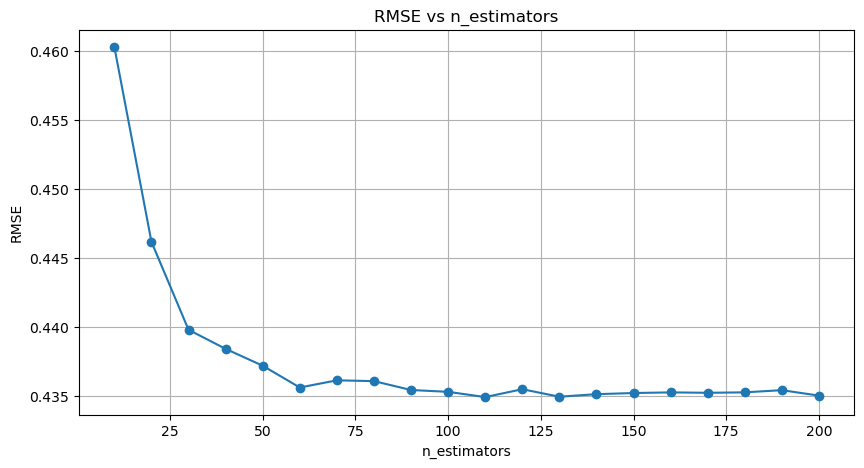

In [12]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(ns, results, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs n_estimators')
plt.grid(True)
plt.show()

In [13]:
# determine earliest n after which RMSE stops improving within 1e-3 of global min
min_rmse = min(results)
min_rmse_idx = results.index(min_rmse)
min_rmse_n = ns[min_rmse_idx]

# earliest n where RMSE is within 1e-3 of global min
threshold = 1e-3
earliest_stable_n = None
for i, val in enumerate(results):
    if val <= min_rmse + threshold:
        earliest_stable_n = ns[i]
        break

print('RMSEs (3 decimals):')
print([round(x, 3) for x in results])
print('\nGlobal min RMSE:', round(min_rmse, 3), 'at n_estimators =', min_rmse_n)
print('Earliest n where RMSE within 1e-3 of min:', earliest_stable_n)

RMSEs (3 decimals):
[np.float64(0.46), np.float64(0.446), np.float64(0.44), np.float64(0.438), np.float64(0.437), np.float64(0.436), np.float64(0.436), np.float64(0.436), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435)]

Global min RMSE: 0.435 at n_estimators = 110
Earliest n where RMSE within 1e-3 of min: 60


### Question 4 — Best max_depth (mean RMSE over n_estimators)

Try max_depth in [10,15,20,25]. For each, test n_estimators from 10 to 200 step 10, compute RMSEs and then mean RMSE (across n_estimators).

In [14]:
# Q4: evaluate mean RMSE for each max_depth
max_depths = [10, 15, 20, 25]
ns = list(range(10, 201, 10))
mean_rmses = {}
for md in max_depths:
    rmses = []
    for n in ns:
        print(f'MD value: {md} --- working on {n}')
        rf = RandomForestRegressor(n_estimators=n, max_depth=md, random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_train, y_train)
        preds = rf.predict(X_val)
        rmses.append(rmse(y_val, preds))
    mean_rmses[md] = np.mean(rmses)

for md, m in mean_rmses.items():
    print(f'max_depth={md}, mean RMSE across n_estimators: {m:.4f}')

best_md = min(mean_rmses, key=mean_rmses.get)
print('\nBest max_depth (by mean RMSE):', best_md)

MD value: 10 --- working on 10
MD value: 10 --- working on 20
MD value: 10 --- working on 30
MD value: 10 --- working on 40
MD value: 10 --- working on 50
MD value: 10 --- working on 60
MD value: 10 --- working on 70
MD value: 10 --- working on 80
MD value: 10 --- working on 90
MD value: 10 --- working on 100
MD value: 10 --- working on 110
MD value: 10 --- working on 120
MD value: 10 --- working on 130
MD value: 10 --- working on 140
MD value: 10 --- working on 150
MD value: 10 --- working on 160
MD value: 10 --- working on 170
MD value: 10 --- working on 180
MD value: 10 --- working on 190
MD value: 10 --- working on 200
MD value: 15 --- working on 10
MD value: 15 --- working on 20
MD value: 15 --- working on 30
MD value: 15 --- working on 40
MD value: 15 --- working on 50
MD value: 15 --- working on 60
MD value: 15 --- working on 70
MD value: 15 --- working on 80
MD value: 15 --- working on 90
MD value: 15 --- working on 100
MD value: 15 --- working on 110
MD value: 15 --- working o

### Question 5 — Feature importances

Train RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1) and print feature importances. Identify the most important among: vehicle_weight, horsepower, acceleration, engine_displacement.

In [15]:
# Q5: feature importances
rf_fi = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_fi.fit(X_train, y_train)
importances = rf_fi.feature_importances_
feat_names = dv.get_feature_names_out()

# Create a DataFrame for convenience
fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_df.head(20)

# Check the specific features
candidates = ['vehicle_weight', 'horsepower', 'acceleration', 'engine_displacement']
candidate_importances = {f: fi_df.loc[fi_df['feature'].str.contains(f), 'importance'].sum() for f in candidates}

print('Candidate importances:')
for k, v in candidate_importances.items():
    print(k, v)

best_candidate = max(candidate_importances, key=candidate_importances.get)
print('\nMost important among candidates:', best_candidate)


Candidate importances:
vehicle_weight 0.9598782143148441
horsepower 0.015933481489766168
acceleration 0.011442313735237557
engine_displacement 0.003159424030350312

Most important among candidates: vehicle_weight


### Question 6 — XGBoost: compare eta=0.3 vs eta=0.1

Train XGBoost models for 100 rounds with parameters provided and compare RMSE on validation. We'll try to install xgboost if needed.

In [18]:
# Q6: XGBoost training (may need to install xgboost first)
try:
    import xgboost as xgb
    print('xgboost version', xgb.__version__)
except Exception as e:
    print('xgboost not available yet:', e)
    # We'll install via notebook_install_packages before running this cell for real

xgboost version 3.1.1


In [19]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
watchlist = [(dtrain, 'train'), (dval, 'val')]

def train_xgb_and_get_val_rmse(eta):
    params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'reg:squarederror',
        'nthread': 8,
        'seed': RANDOM_STATE,
        'verbosity': 1,
    }
    bst = xgb.train(params, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=False)
    preds_val = bst.predict(dval)
    return rmse(y_val, preds_val)

rmse_eta_03 = train_xgb_and_get_val_rmse(0.3)
rmse_eta_01 = train_xgb_and_get_val_rmse(0.1)
print('RMSE eta=0.3:', rmse_eta_03)
print('RMSE eta=0.1:', rmse_eta_01)
if abs(rmse_eta_03 - rmse_eta_01) < 1e-9:
    print('Both give equal value')
elif rmse_eta_03 < rmse_eta_01:
    print('eta=0.3 gives better RMSE')
else:
    print('eta=0.1 gives better RMSE')

RMSE eta=0.3: 0.44340462733166064
RMSE eta=0.1: 0.4167428683326873
eta=0.1 gives better RMSE


## Summary of answers

# We'll collect the key outputs printed above when the notebook runs. The section above prints the answers for Q1..Q6.

print('Run all code cells to obtain final answers printed above.')


In [8]:
# Define helper functions again (ensure available after kernel restart)
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def train_model_return_rmse(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return rmse(y_val, preds)


In [10]:
# Redefine rmse to be compatible with older sklearn
import numpy as np
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


In [ ]:
# Q3 (optimized): train a single RandomForest with 200 trees and compute RMSE for subsets of trees
ns = list(range(10, 201, 10))
rf200 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf200.fit(X_train, y_train)

# Compute predictions using first n estimators
results = []
for n in ns:
    preds_per_tree = np.column_stack([est.predict(X_val) for est in rf200.estimators_[:n]])
    preds_mean = preds_per_tree.mean(axis=1)
    results.append(rmse(y_val, preds_mean))

plt.figure(figsize=(10,5))
plt.plot(ns, results, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs n_estimators (computed from first 200-tree model)')
plt.grid(True)
plt.show()

min_rmse = min(results)
min_rmse_idx = results.index(min_rmse)
min_rmse_n = ns[min_rmse_idx]

threshold = 1e-3
earliest_stable_n = None
for i, val in enumerate(results):
    if val <= min_rmse + threshold:
        earliest_stable_n = ns[i]
        break

print('RMSEs (3 decimals):')
print([round(x, 3) for x in results])
print('\nGlobal min RMSE:', round(min_rmse, 3), 'at n_estimators =', min_rmse_n)
print('Earliest n where RMSE within 1e-3 of min:', earliest_stable_n)
